##Problem Statement -
You have been given the dataset of all the adult individuals in US. your objective is to build a Naïve Bayes algorithm to predict if an adult earn >50k or <=50k. use Naïve Bayes with sklearn.naive_bayes.GaussianNB.

##Understanding the dataset -
Input (Independent) Variables: The input variables are age, workclass, fnlwgt, education, education.num, marital.status, occupation, relationship, race, gender, capital.gain, capital.loss, hours.per.week, and native.country, which are used to predict an individual's income.
Target (Dependent) Variable: The target/output variable is income, which classifies whether an individual's annual income is >50K or <=50K.

In [ ]:
#Importing all the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report, precision_score, recall_score, f1_score

In [ ]:
# Loading the humans dataset into a Pandas DataFrame.
df = pd.read_csv('/content/Humans dataset.csv')

In [ ]:
# Displaying the first five records to verify that the dataset has been loaded correctly.
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,gender,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


#EDA Begins

In [ ]:
# Checking the number of rows and columns present in the dataset.
df.shape

(32561, 15)

The dataset contains 32561 patient records and 15 columns.

In [ ]:
# Displaying dataset information, including data types, non-null counts, and memory usage.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   gender          32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [ ]:
# Generating descriptive statistics for all numerical features.
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,32561.0,38.581647,13.640433,17.0,28.0,37.0,48.0,90.0
fnlwgt,32561.0,189778.366512,105549.977697,12285.0,117827.0,178356.0,237051.0,1484705.0
education.num,32561.0,10.080679,2.572720,1.0,9.0,10.0,12.0,16.0
capital.gain,32561.0,1077.648844,7385.292085,0.0,0.0,0.0,0.0,99999.0
capital.loss,32561.0,87.303830,402.960219,0.0,0.0,0.0,0.0,4356.0
hours.per.week,32561.0,40.437456,12.347429,1.0,40.0,40.0,45.0,99.0


In [ ]:
(df == "?").sum()

,0
age,0
workclass,1836
fnlwgt,0
education,0
education.num,0
marital.status,0
occupation,1843
relationship,0
race,0
gender,0


In [ ]:
# Replace '?' error values with NaN for easier handling of missing data
df.replace("?", np.nan, inplace=True)

In [ ]:
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,gender,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,NaN,77053,HS-grad,9,Widowed,NaN,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,NaN,186061,Some-college,10,Widowed,NaN,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [ ]:
# Identifying columns in which every value is unique.
unique_columns = [col for col in df.columns if df[col].nunique() == len(df)]
print(unique_columns)


[]


No columns contain entirely unique values. Therefore, no identifier column needs to be removed.

In [ ]:
# Checking for missing values in each column.
df.isnull().sum()

,0
age,0
workclass,1836
fnlwgt,0
education,0
education.num,0
marital.status,0
occupation,1843
relationship,0
race,0
gender,0


In [ ]:
# Handling missing values by replacing categorical features with mode.
for col in ['workclass','occupation','native.country']:
    df[col].fillna(df[col].mode()[0], inplace=True)

In [ ]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education.num,0
marital.status,0
occupation,0
relationship,0
race,0
gender,0


In [ ]:
# Checking for duplicate records in the dataset
df.duplicated().sum()

np.int64(24)

24 duplicate records were found in the dataset, indicating that duplicate removal is required.

In [ ]:
#Removing the duplicate records
df.drop_duplicates(inplace=True)

In [ ]:
df.shape

(32537, 15)

In [ ]:
# Separating categorical (object) and numerical columns for independent analysis
cat = df.select_dtypes(include = "object").columns
num = df.select_dtypes(exclude= "object").columns

In [ ]:
cat

Index(['workclass', 'education', 'marital.status', 'occupation',
       'relationship', 'race', 'gender', 'native.country', 'income'],
      dtype='object')

In [ ]:
num

Index(['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss',
       'hours.per.week'],
      dtype='object')

### Detailed Outlier Detection and Handling for Numerical Features

In [ ]:
for col in num:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"Column: {col}")
    print(f"  Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
    print(f"  Lower Bound: {lower_bound}, Upper Bound: {upper_bound}")
    print(f"  Number of Outliers: {len(outliers)}")
    print("\n")

    # Capping outliers
    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])

print("Outliers have been capped for all numerical columns.")

Column: age
  Q1: 28.0, Q3: 48.0, IQR: 20.0
  Lower Bound: -2.0, Upper Bound: 78.0
  Number of Outliers: 142


Column: fnlwgt
  Q1: 117827.0, Q3: 236993.0, IQR: 119166.0
  Lower Bound: -60922.0, Upper Bound: 415742.0
  Number of Outliers: 993


Column: education.num
  Q1: 9.0, Q3: 12.0, IQR: 3.0
  Lower Bound: 4.5, Upper Bound: 16.5
  Number of Outliers: 1193


Column: capital.gain
  Q1: 0.0, Q3: 0.0, IQR: 0.0
  Lower Bound: 0.0, Upper Bound: 0.0
  Number of Outliers: 2712


Column: capital.loss
  Q1: 0.0, Q3: 0.0, IQR: 0.0
  Lower Bound: 0.0, Upper Bound: 0.0
  Number of Outliers: 1519


Column: hours.per.week
  Q1: 40.0, Q3: 45.0, IQR: 5.0
  Lower Bound: 32.5, Upper Bound: 52.5
  Number of Outliers: 9002


Outliers have been capped for all numerical columns.


In [ ]:
# Display descriptive statistics after capping to see the effect
display(df[num].describe().T)

,count,mean,std,min,25%,50%,75%,max
age,32537.0,38.559855,13.554847,17.0,28.0,37.0,48.0,78.0
fnlwgt,32537.0,186824.961736,95118.115529,12285.0,117827.0,178356.0,236993.0,415742.0
education.num,32537.0,10.125165,2.459436,4.5,9.0,10.0,12.0,16.0
capital.gain,32537.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
capital.loss,32537.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
hours.per.week,32537.0,41.203246,6.187352,32.5,40.0,40.0,45.0,52.5


In [ ]:
# Drop 'capital.gain' and 'capital.loss' columns as they now contain only zeros after capping
df.drop(columns=['capital.gain', 'capital.loss'], inplace=True)

print("Columns 'capital.gain' and 'capital.loss' have been dropped.")
display(df.head())

Columns 'capital.gain' and 'capital.loss' have been dropped.


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,gender,hours.per.week,native.country,income
0,78.0,Private,77053.0,HS-grad,9.0,Widowed,Prof-specialty,Not-in-family,White,Female,40.0,United-States,<=50K
1,78.0,Private,132870.0,HS-grad,9.0,Widowed,Exec-managerial,Not-in-family,White,Female,32.5,United-States,<=50K
2,66.0,Private,186061.0,Some-college,10.0,Widowed,Prof-specialty,Unmarried,Black,Female,40.0,United-States,<=50K
3,54.0,Private,140359.0,7th-8th,4.5,Divorced,Machine-op-inspct,Unmarried,White,Female,40.0,United-States,<=50K
4,41.0,Private,264663.0,Some-college,10.0,Separated,Prof-specialty,Own-child,White,Female,40.0,United-States,<=50K


### Label Encoding Categorical Features

In [ ]:
# Encode categorical (object) columns into numeric values using Label Encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

display(df.head())

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,gender,hours.per.week,native.country,income
0,78.0,3,77053.0,11,9.0,6,9,1,4,0,40.0,38,0
1,78.0,3,132870.0,11,9.0,6,3,1,4,0,32.5,38,0
2,66.0,3,186061.0,15,10.0,6,9,4,2,0,40.0,38,0
3,54.0,3,140359.0,5,4.5,0,6,4,4,0,40.0,38,0
4,41.0,3,264663.0,15,10.0,5,9,3,4,0,40.0,38,0


### Univariate Analysis: Histograms

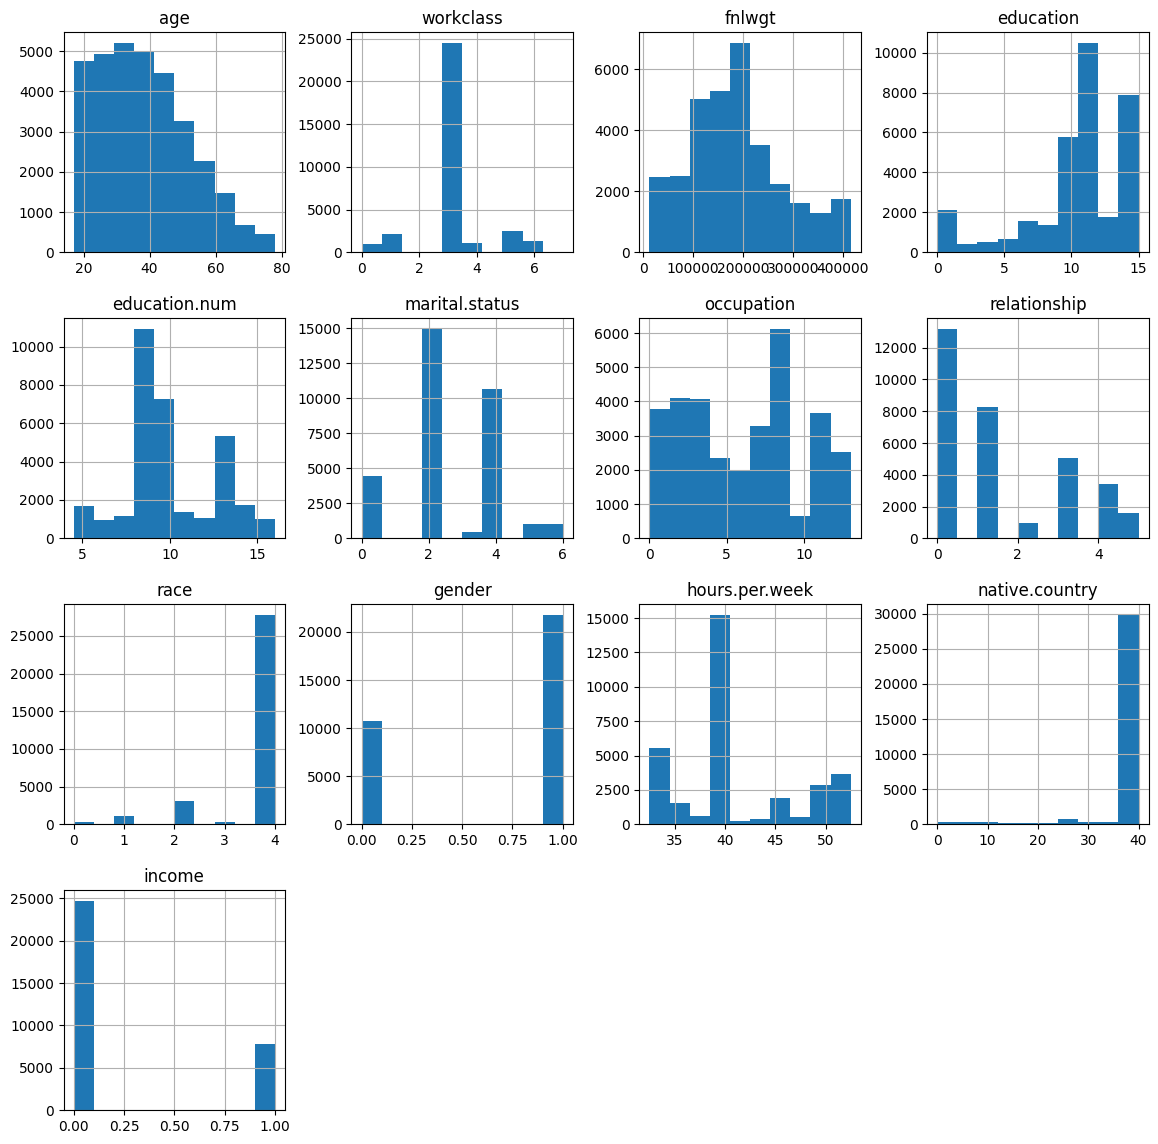

In [ ]:
#Univariate analysis
# Visualizing the distribution of each numerical feature using histograms.
df.hist(figsize=(14,14))
plt.show()


### Bivariate Analysis

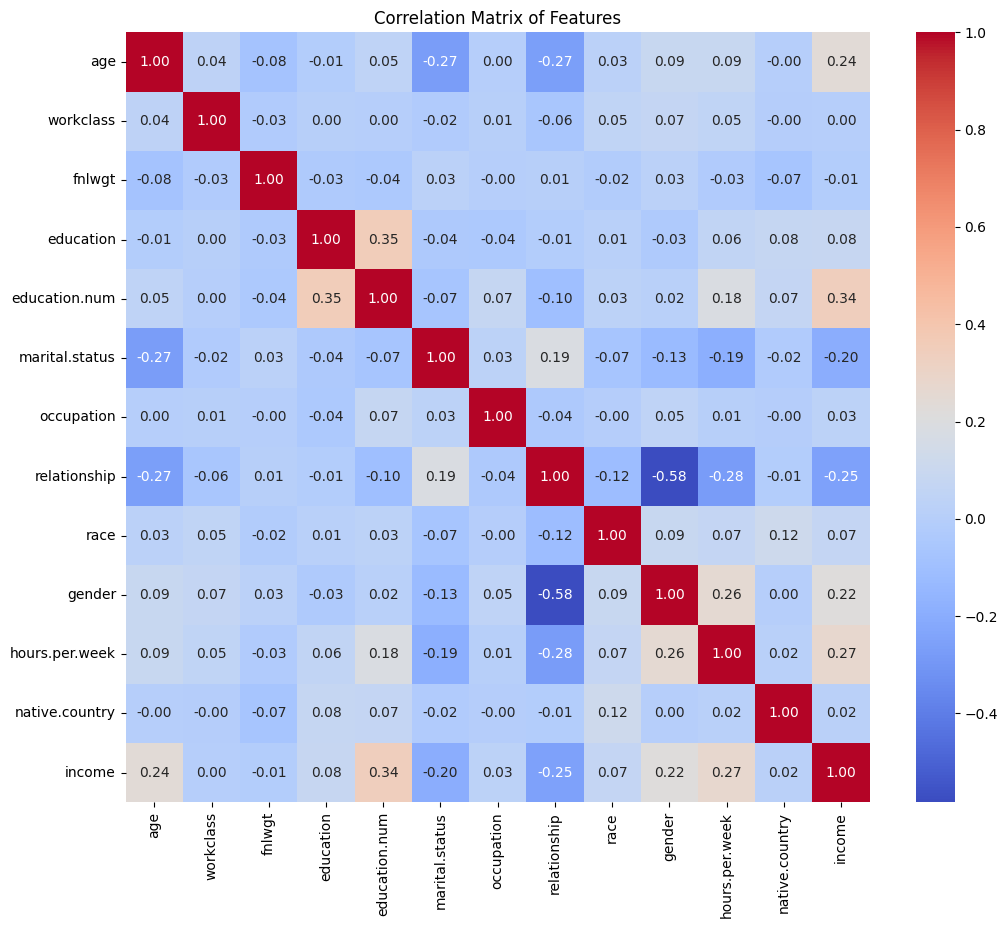

In [ ]:
#Bivariate analysis
# correlation matrix
# Analyzing relationships between features using a correlation heatmap.

plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot = True, cmap = 'coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Features')
plt.show()


ML Model Building

In [ ]:
# Separating independent features (X) and the target variable (y).
x=df.drop('income',axis=1)
y=df['income']

In [ ]:
x.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,gender,hours.per.week,native.country
0,78.0,3,77053.0,11,9.0,6,9,1,4,0,40.0,38
1,78.0,3,132870.0,11,9.0,6,3,1,4,0,32.5,38
2,66.0,3,186061.0,15,10.0,6,9,4,2,0,40.0,38
3,54.0,3,140359.0,5,4.5,0,6,4,4,0,40.0,38
4,41.0,3,264663.0,15,10.0,5,9,3,4,0,40.0,38


In [ ]:
y.head()

,income
0,0
1,0
2,0
3,0
4,0


In [ ]:
# Splitting the dataset into training and testing sets
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
# Training the Logistic Regression model
model = GaussianNB()
model.fit(x_train, y_train)

GaussianNB()

In [ ]:
# Predicting heart disease risk for the test dataset.
y_pred = model.predict(x_test)

In [ ]:
y_pred

array([0, 0, 0, ..., 0, 0, 0])

In [ ]:
# Evaluating the model using Accuracy, Precision, Recall, F1-score, and Confusion Matrix.
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("Confusion Matrix:\n", conf_matrix)

Accuracy: 0.7907191149354641
Precision: 0.5851293103448276
Recall: 0.35723684210526313
F1 Score: 0.44362745098039214
Confusion Matrix:
 [[4603  385]
 [ 977  543]]


In [ ]:
df['income'].value_counts(normalize=True) * 100

,proportion
income,
0,75.907428
1,24.092572
